# Steam Games — Feature Engineering

**Project:** Steam Games Success Analysis  
**Author:** Edwin Chen
**Input:** `data/processed/games_clean.csv` and `data/processed/reviews_agg.csv`  

---

## Overview

With the exploratory analysis complete, this notebook creates a set of derived features designed to make the dataset more useful for dashboard development and business-level interpretation.

Raw numerical columns like `total_reviews` or `metacritic_score` are informative on their own, but they become much more actionable when transformed into categories, composite scores, and binary flags. Each feature built here has a clear purpose tied to the questions the dashboard will answer.

The following features are engineered:

| Feature | Type | Purpose |
|---|---|---|
| `success_score` | Float | Composite KPI combining quality and reach |
| `price_bucket` | Category | Price range segments for filtering |
| `is_free` | Binary | Quick F2P identifier |
| `review_tier` | Category | Game size tier by review volume |
| `release_era` | Category | Steam historical era grouping |
| `is_multiplatform` | Binary | Whether a game supports more than one OS |
| `metacritic_tier` | Category | Human-readable critic score grouping |
| `playtime_capped` | Float | Playtime with outliers removed |
| `genre_*` | Binary flags | One-hot encoding of top 10 genres |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
# Apply consistent visual 
sns.set_theme(style='darkgrid', palette='muted') 
# Default plot settigs
plt.rcParams.update({ 
    "figure.dpi" : 150,
    "axes.titlesize" : 13,
    "axes.labelsize" : 12,
    "axes.titleweight" : "bold",
})
# Load clean games dataset
games = pd.read_csv('../data/processed/games_clean.csv', dtype={'appID': str})
rev_agg = pd.read_csv('../data/processed/reviews_agg.csv', dtype={'app_id': str})

print(f'Games: {games.shape}')
print(f'Reviews agg: {rev_agg.shape}')

Games: (124146, 35)
Reviews agg: (332, 5)


In [2]:
# Recreate derived columns from EDA
games['total_reviews'] = games['positive'] + games['negative']
games['positive_rate'] = np.where(
    games['total_reviews'] > 0,
    games['positive'] / games['total_reviews'],
    np.nan
)

# Work only with games that have at least 10 reviews
# Games with fewer reviews are too noisy for reliable analysis
games_reviewed = games[games['total_reviews'] >= 10].copy()
games_featured = games_reviewed.copy()
# Recreate platform_count
games_featured['platform_count'] = (
    games_featured['windows'].astype(int) +
    games_featured['mac'].astype(int) +
    games_featured['linux'].astype(int)
)

print(f'Games with >= 10 reviews: {len(games_featured):,}')

Games with >= 10 reviews: 56,657


---
## 1. Success Score

The first challenge in this project is defining what "success" actually means for a Steam game. There is no single column in the dataset that answers that question cleanly.

`positive_rate` alone is not enough. A game with 10 reviews and a 90% positive rate is not comparable to one with 500,000 reviews and an 85% rate. The second game is clearly more successful, but a simple ratio would rank them similarly.

To solve this, the success score combines both dimensions: quality (positive rate) and reach (review volume). Review count is log-transformed to avoid giving outsized weight to blockbuster titles, while still rewarding games that have built a meaningful audience.

The formula is: `success_score = positive_rate x log(1 + total_reviews)`

This becomes the primary KPI of the project and will be used as the main axis in the dashboard.

In [3]:
# success_score: composite metric combining quality and reach
# positive_rate captures user satisfaction
# log1p(total_reviews) dampens the effect of extreme review counts
# and avoids penalizing games with very few reviews
games_featured['success_score'] = games_featured['positive_rate'] * np.log1p(games_featured['total_reviews'])

print('Success score distribution:')
print(games_featured['success_score'].describe())
print(f'\nTop 5 by success_score:')
print(games_featured[['name', 'positive_rate', 'total_reviews', 'success_score']]
      .sort_values('success_score', ascending=False).head())

Success score distribution:
count    56657.000000
mean         3.618916
std          1.834661
min          0.000000
25%          2.370230
50%          3.169074
75%          4.511767
max         13.863961
Name: success_score, dtype: float64

Top 5 by success_score:
                     name  positive_rate  total_reviews  success_score
45509    Counter-Strike 2       0.866932        8815087      13.863961
10927            Terraria       0.974818        1409473      13.802176
35440         Garry's Mod       0.967957        1159707      13.516235
44134  Black Myth: Wukong       0.966631        1150098      13.489678
95880      Stardew Valley       0.984415         886195      13.481267


### Result

The top 5 games by success score are CS:GO, Terraria, Garry's Mod, Black Myth: Wukong, and Stardew Valley. These are all titles that combine an exceptionally high positive rate with hundreds of thousands or millions of reviews, which is exactly the behavior the metric is designed to surface. The score distribution has a mean around 3.6 and a max of ~13.9, giving the dashboard a meaningful range to work with.

---
## 2. Price Bucket

Raw price values are hard to interpret in aggregate visualizations. Grouping games into price ranges makes it easier to compare segments and spot patterns in user satisfaction or ownership across different price points.

The boundaries are chosen to reflect how games are actually priced on Steam: a large volume of titles under `$5`, a sweet spot around `$10-20` for mid-range games, and a smaller premium tier above `$30`.

In [4]:
# Group price into segments that reflect real Steam pricing patterns
price_bins   = [0, 0.01, 5, 10, 20, 30, 9999]
price_labels = ['F2P', '$0-5', '$5-10', '$10-20', '$20-30', '$30+']

games_featured['price_bucket'] = pd.cut(games_featured['price'],bins=price_bins,labels=price_labels,right=False)

print('Price bucket distribution:')
print(games_featured['price_bucket'].value_counts().sort_index())

Price bucket distribution:
price_bucket
F2P        7382
$0-5      32665
$5-10      9972
$10-20     5409
$20-30      775
$30+        454
Name: count, dtype: int64


---
## 3. Is Free (F2P Flag)

Free to Play games behave differently from paid titles across almost every metric: they tend to have larger audiences, higher variance in ratings, and different engagement patterns. A simple binary flag makes it easy to isolate this segment in the dashboard.

In [5]:
# Binary flag: 1 if the game is Free to Play, 0 if paid
games_featured['is_free'] = (games_featured['price'] == 0).astype(int)

print(f'Free to Play: {games_featured["is_free"].sum():,}')
print(f'Paid: {(games_featured["is_free"] == 0).sum():,}')

Free to Play: 7,382
Paid: 49,275


---
## 4. Review Tier

Review volume follows a power-law distribution, which means that most games sit in a completely different league from the handful of titles that have millions of reviews. Treating all of them as a single group in visualizations leads to charts that are dominated by a few outliers.

The tier thresholds are based on the distribution observed in the EDA. Since `games_reviewed` already filters for games with at least 10 reviews, the lowest tier here is Niche rather than No Reviews.

In [6]:
# Segment games by review volume into four meaningful tiers
# Thresholds reflect natural breakpoints in the power-law distribution
review_bins = [10,100,1000,10000, float('inf')]
review_labels = ['Niche', 'Mid', 'Popular', 'Blockbuster']

games_featured['review_tier'] = pd.cut(games_featured['total_reviews'], bins= review_bins, labels= review_labels, right=False)

print('Review tier distribution:')
print(games_featured['review_tier'].value_counts().sort_index())

Review tier distribution:
review_tier
Niche          33856
Mid            15594
Popular         5506
Blockbuster     1701
Name: count, dtype: int64


### Result

The vast majority of games fall into the **Niche** tier (under 100 reviews), which confirms what the EDA showed: most Steam games are small releases that never gain significant traction. Only 1,701 games qualify as **Blockbuster** titles with over 10,000 reviews.

---
## 5. Release Era


The temporal analysis showed that Steam has gone through distinct phases driven by platform policy changes. Rather than working with individual years, grouping releases into eras makes it easier to compare how the landscape has shifted over time.

The four eras reflect real platform milestones:
- **Early Steam** (before 2012): a curated, small catalog
- **Greenlight Era** (2012-2016): community voting opened the doors to indie games
- **Direct Era** (2017-2020): Steam Direct replaced Greenlight, dramatically lowering the barrier to publishing
- **Modern** (2021+): post-pandemic growth and continued catalog expansion

In [7]:
def assign_era(year):
    if year < 2012:
        return 'Early Steam'
    elif year < 2017:
        return 'Greenlight Era'
    elif year < 2021:
        return 'Direct Era'
    else:
        return 'Modern'

games_featured['release_era'] = games_featured['release_year'].apply(assign_era)

# Ordered categorical so charts display eras in chronological order
era_order = ['Early Steam', 'Greenlight Era', 'Direct Era', 'Modern']
games_featured['release_era'] = pd.Categorical(games_featured['release_era'], categories=era_order, ordered=True)

print('Release era distribution:')
print(games_featured['release_era'].value_counts().sort_index())

Release era distribution:
release_era
Early Steam        1125
Greenlight Era     8416
Direct Era        20311
Modern            26805
Name: count, dtype: int64


### Result

The distribution follows the platform's history closely. The **Modern era (2021+)** 
has the largest share with 26,805 games, reflecting the continued acceleration of 
releases post-Steam Direct. The **Direct Era (2017-2020)** comes second with 20,311 
games. The Early Steam period accounts for only 1,125 games in the reviewed dataset, 
confirming that the pre-Greenlight catalog was small and curated compared to what 
the platform looks like today.

---
## 6. Is Multiplatform

The platform analysis found that games supporting more than one operating system tend to have higher positive rates and ownership figures. This binary flag captures that distinction simply, without needing to reference the raw platform columns.

In [8]:
# Binary flag: 1 if the game supports more than one OS (Win + Mac and/or Linux)
games_featured['is_multiplatform'] = (games_featured['platform_count'] > 1).astype(int)

print(f'Multiplatform: {games_featured["is_multiplatform"].sum():,}')
print(f'Windows-only: {(games_featured["is_multiplatform"]==0).sum():,}')

Multiplatform: 15,154
Windows-only: 41,503


### Result

About **27% of reviewed games support more than one platform**, while the remaining 
73% are Windows-only. This split is consistent with what the platform analysis in 
the EDA showed: multi-platform support is a meaningful differentiator, but it 
remains the exception rather than the rule on Steam.

---
## 7. Metacritic Tier

Over 52,000 games in the reviewed dataset have a Metacritic score of 0, meaning they were never reviewed by critics. Using this column as a raw numeric would be misleading, since 0 would be confused with a genuinely terrible score.

Converting it to a categorical tier solves this problem cleanly and makes the column much more readable in a dashboard context. The score boundaries follow standard conventions used in game journalism.

In [9]:
# Convert Metacritic score to a human-readable tier
# Score of 0 means no Metacritic entry, not a bad game

def metacritic_tier(score):
    if score == 0:
        return 'No Score'
    elif score < 60:
        return 'Mixed'
    elif score < 75:
        return 'Good'
    elif score < 90:
        return 'Very Good'
    else:
        return 'Outstanding'

games_featured['metacritic_tier'] = games_featured['metacritic_score'].apply(metacritic_tier)

tier_order = ['No Score', 'Mixed', 'Good', 'Very Good', 'Outstanding']
games_featured['metacritic_tier']= pd.Categorical(games_featured['metacritic_tier'], categories=tier_order, ordered=True)

print('Metacritic tier distribution:')
print(games_featured['metacritic_tier'].value_counts().sort_index())

Metacritic tier distribution:
metacritic_tier
No Score       52512
Mixed            384
Good            1512
Very Good       2130
Outstanding      119
Name: count, dtype: int64


### Result

The most important finding here is that **92.7% of games have no Metacritic score 
at all**. Critics simply do not review the vast majority of Steam releases. Among 
the games that do have a score, most fall into the Good or Very Good tier, with only 
119 games reaching Outstanding (90+). This confirms that Metacritic score is useful 
as a filter for a small premium segment of the catalog, not as a general quality 
signal across the full dataset.

---
## 8. Playtime (Capped)

The raw `average_playtime_forever` column has a maximum value of over 3.4 million minutes, which is roughly 6.5 years of continuous playtime. That is clearly erroneous data, likely caused by always-on services or corrupted records in the Steam API.

Rather than dropping these games entirely, the playtime value is capped at the 99th percentile. This preserves the full dataset while preventing a handful of bad data points from distorting any visualizations that use playtime.

In [10]:
# Cap playtime at the 99th percentile to remove physically impossible values
# The raw max of ~3.4M minutes (~6.5 years) is clearly erroneous
playtime_cap = games_featured['average_playtime_forever'].quantile(0.99)
games_featured['playtime_capped'] = games_featured['average_playtime_forever'].clip(upper=playtime_cap)

print(f'PLaytime cap (99th pct): {playtime_cap:,.0f} minutes ({playtime_cap/60:.0f} hours)')
print(games_featured['playtime_capped'].describe())

PLaytime cap (99th pct): 4,327 minutes (72 hours)
count    56657.000000
mean       211.422400
std        596.643762
min          0.000000
25%          0.000000
50%          0.000000
75%        173.000000
max       4326.760000
Name: playtime_capped, dtype: float64


### Result

The 99th percentile cap lands at **4,327 minutes (roughly 72 hours)**, which is a 
reasonable upper bound for average playtime. The median remains at 0 even after 
capping, which reflects what the EDA showed: most games in the dataset have very 
low engagement data recorded, either because they were never played long enough to 
generate meaningful Steam stats, or because playtime tracking was not available for 
older titles.

---
## 9. Genre One-Hot Flags

The `genres` column stores multiple genres as a comma-separated string, which is not directly usable for filtering in a dashboard. Creating a binary flag for each of the top 10 genres makes it straightforward to slice the data by genre without string parsing at query time.

The top 10 genres were identified in the EDA and cover the vast majority of the catalog.

In [11]:
# One-hot encode the top 10 genres identified in the EDA
# Each flag is 1 if the game belongs to that genre, 0 otherwise
top_genres = [
    'Indie', 'Action', 'Adventure', 'Casual', 'Simulation',
    'Strategy', 'RPG', 'Free To Play', 'Sports', 'Racing'
]

for genre in top_genres:
    col_name = f"genre_{genre.lower().replace(' ', '_')}"
    games_featured[col_name] = games_featured['genres'].str.contains(genre, na=False).astype(int)

genre_flag_cols = [c for c in games_featured.columns if c.startswith('genre_')]

print('Genre flags created:')
print(games_featured[genre_flag_cols].sum().sort_values(ascending=False))

Genre flags created:
genre_indie           40581
genre_adventure       23959
genre_action          23895
genre_casual          21803
genre_simulation      12657
genre_strategy        11612
genre_rpg             10950
genre_free_to_play     4231
genre_sports           2540
genre_racing           2053
dtype: int64


### Result

The flags confirm the genre distribution found in the EDA. **Indie** is by far the 
largest category with 40,581 games, followed by **Adventure** (23,959) and **Action** 
(23,895). The smallest categories in this selection are **Racing** (2,053) and 
**Sports** (2,540). These flags will be the primary genre filter in the dashboard, 
covering the large majority of the catalog without requiring any string parsing at 
query time.

---
## 10. Validation and Save

Before saving, a final check confirms that all new features were created correctly and that no nulls were introduced.

In [12]:
# Final validation
new_cols = [
    'success_score', 'price_bucket', 'is_free', 'review_tier',
    'release_era', 'is_multiplatform', 'metacritic_tier', 'playtime_capped'
] + genre_flag_cols

print(f'New features added: {len(new_cols)}')
print(f'Final shape: {games_featured.shape}')
print(f'\nNulls in new features:')
nulls = games_featured[new_cols].isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'None')

New features added: 18
Final shape: (56657, 56)

Nulls in new features:
None


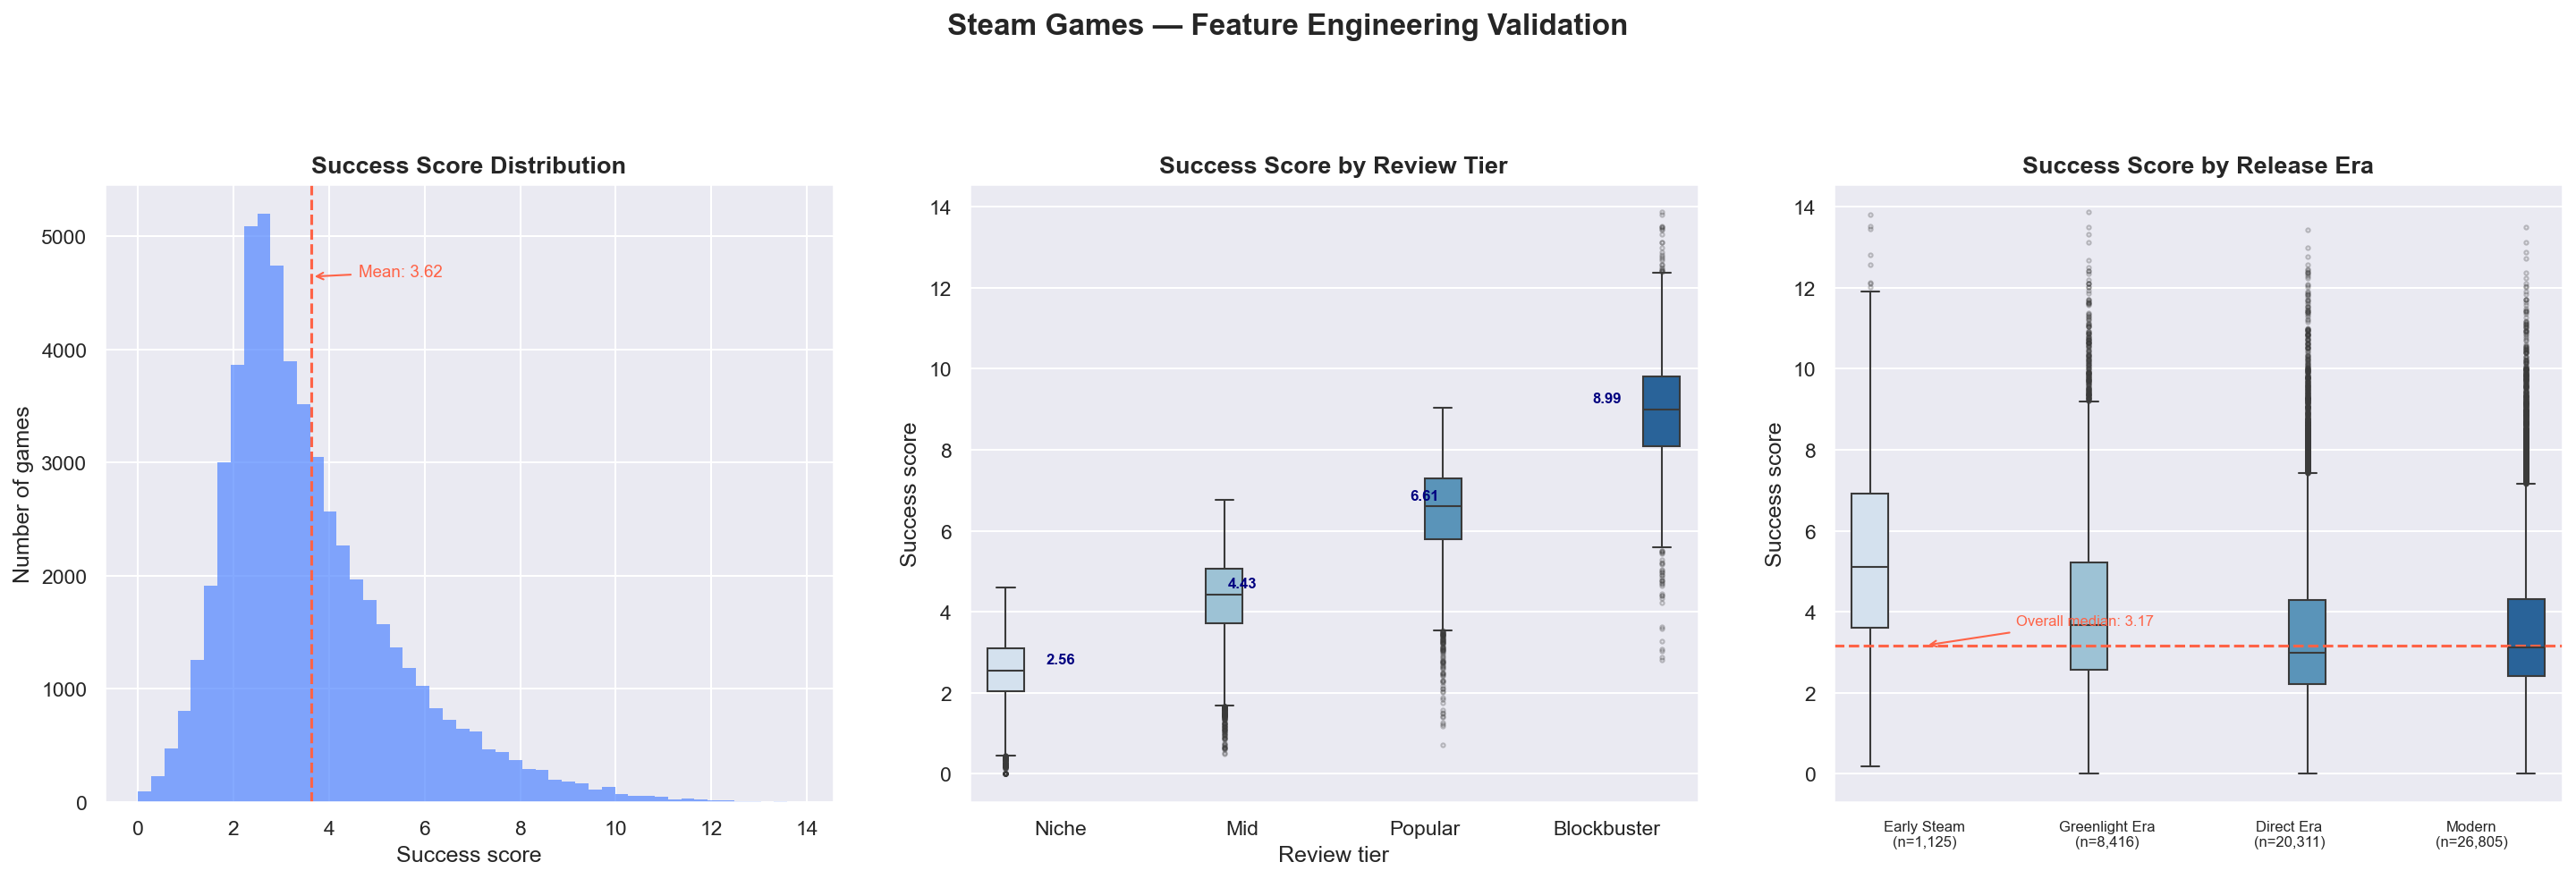

In [16]:
# Validation plots to confirm the engineered features behave as expected 

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Steam Games — Feature Engineering Validation', fontsize=16, fontweight='bold')

# Plot 1: success_score distribution 
ax1 = axes[0]

sns.histplot(games_featured['success_score'],bins=50,ax=ax1,color='#5B8CFF',edgecolor='none')

mean_score = games_featured['success_score'].mean()
ax1.axvline(mean_score, color='tomato', linestyle='--', linewidth=1.5)
ax1.annotate(
    f'Mean: {mean_score:.2f}',
    xy=(mean_score, ax1.get_ylim()[1] * 0.85),
    xytext=(mean_score + 1, ax1.get_ylim()[1] * 0.85),
    arrowprops=dict(arrowstyle='->', color='tomato'),
    color='tomato', fontsize=9
)
ax1.set_title('Success Score Distribution')
ax1.set_xlabel('Success score')
ax1.set_ylabel('Number of games')

# Plot 2: success_score by review_tier 
ax2 = axes[1]

tier_order = ['Niche', 'Mid', 'Popular', 'Blockbuster']

sns.boxplot(
    data=games_featured,
    x='review_tier', y='success_score', hue ='review_tier',
    legend=False,
    order=tier_order,
    ax=ax2,
    palette='Blues',
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

# Median labels on top of each box
for i, tier in enumerate(tier_order):
    median = games_featured[games_featured['review_tier'] == tier]['success_score'].median()
    ax2.text(i, median + 0.1, f'{median:.2f}',
             ha='center', va='bottom', fontsize=8, fontweight='bold', color='navy')

ax2.set_title('Success Score by Review Tier')
ax2.set_xlabel('Review tier')
ax2.set_ylabel('Success score')

# Plot 3: success_score by release_era 
ax3 = axes[2]

era_order = ['Early Steam', 'Greenlight Era', 'Direct Era', 'Modern']

sns.boxplot(
    data=games_featured,
    x='release_era', y='success_score',hue='release_era',
    legend=False,
    order=era_order,
    ax=ax3,
    palette='Blues',
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

# Sample size per era as annotation below x labels
era_counts = games_featured['release_era'].value_counts()
ax3.set_xticks(range(len(era_order)))
ax3.set_xticklabels([
    f'{era}\n(n={era_counts.get(era, 0):,})'
    for era in era_order
], fontsize=8)

# Reference line - overall median
overall_median = games_featured['success_score'].median()
ax3.axhline(overall_median, color='tomato', linestyle='--', linewidth=1.5)
ax3.annotate(
    f'Overall median: {overall_median:.2f}',
    xy=(0, overall_median),
    xytext=(0.5, overall_median + 0.5),
    arrowprops=dict(arrowstyle='->', color='tomato'),
    color='tomato', fontsize=8
)

ax3.set_title('Success Score by Release Era')
ax3.set_xlabel('')
ax3.set_ylabel('Success score')

plt.tight_layout(pad=3)
plt.savefig('../images/06_feature_validation.png', bbox_inches='tight', dpi=150)
plt.show()

In [13]:
# Save the enriched dataset for dashboard use
games_featured.to_csv('../data/processed/games_featured.csv', index=False)
print('Saved to data/processed/games_featured.csv')

Saved to data/processed/games_featured.csv


### What the plots confirm

**Success Score Distribution:** The distribution is right-skewed, which is expected 
given that most games have low review volumes. The bulk of the catalog sits between 
1 and 6, with a small number of titles reaching the 10-14 range. This spread confirms 
the metric has enough range to be useful as a ranking axis in the dashboard.

**Success Score by Review Tier:** The metric separates tiers cleanly where median score 
increases at each step from Niche to Blockbuster. This validates that the formula 
rewards both quality and reach, and that the review tier segments are meaningful 
rather than arbitrary.

**Success Score by Release Era:** Early Steam has the highest median (~5.0), 
reflecting a small, curated catalog of titles that have stood the test of time. 
Both the Direct Era and Modern era sit below the overall median of 3.17, which 
supports the idea that the flood of releases post-2017 diluted average perceived 
quality. The Greenlight Era sits just above the median, acting as a transition 
period between the curated early catalog and the open publishing model that followed.

---
## Summary

All 18 engineered features were created without introducing any nulls into the dataset.

| Feature | Notes |
|---|---|
| `success_score` | Top 5 are CS:GO, Terraria, Garry's Mod, Black Myth: Wukong, Stardew Valley |
| `price_bucket` | Most games priced under `$5`; only ~454 above `$30` |
| `is_free` | 7,382 F2P games vs 49,275 paid |
| `review_tier` | 33,856 Niche / 15,594 Mid / 5,506 Popular / 1,701 Blockbuster |
| `release_era` | Modern (2021+) has the largest share with 26,805 games |
| `is_multiplatform` | 15,154 multiplatform vs 41,503 Windows-only |
| `metacritic_tier` | 92.7% of games have no Metacritic score at all |
| `playtime_capped` | Cap set at 4,327 minutes (72 hours) |
| `genre_*` flags | Indie is the largest category with 40,581 games |

The enriched dataset `games_featured.csv` is ready for the dashboard.